# GDP y OECD en Ciencia de Datos
## Contexto y definiciones clave

---

## ¿Qué es GDP?

**GDP** (*Gross Domestic Product*)  
En español: **Producto Interno Bruto (PIB)**

---

## ¿Qué mide el GDP?

- Tamaño de la economía
- Nivel de actividad económica
- Indicador macroeconómico de desarrollo

> ⚠️ No mide directamente bienestar o calidad de vida

## GDP per capita

$
\text{GDP per capita} = \frac{\text{GDP total}}{\text{Población}}
$

---

## ¿Qué es la OECD?

**OECD**  
(*Organisation for Economic Co-operation and Development*)

En español:
> **Organización para la Cooperación y el Desarrollo Económicos (OCDE)**

## Satisfacción con la vida (OECD)
Indicador:
- *Life satisfaction*
- Escala típica: 0–10
- Basado en encuestas poblacionales
Usado como:
> Variable objetivo (label) en modelos

---

# Base de datos

(Nuestras bases de datos se encontraran en la carpeta datasets/lifesat)

---

Estas bases de datos provienen de la OECD 

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

---

## Analisis exploratorio

---

Las bases de datos obtenidas tienen informacion que no es de nuestro interes, por lo que procederemos a generar dataframes con la informacion de interes

In [2]:
Datapath = Path("datasets") / "lifesat"
Datapath.mkdir(parents=True, exist_ok=True)

GDP = pd.read_csv(Datapath / "GDP_last_5.csv")
life = pd.read_csv(Datapath / "life_satisfaction().csv")

In [3]:
GDP = GDP[['Reference area','Transaction','Unit of measure','Price base', 'TIME_PERIOD', 'OBS_VALUE', 'Confidentiality status']]
GDP.head()

,Reference area,Transaction,Unit of measure,Price base,TIME_PERIOD,OBS_VALUE,Confidentiality status
0,Colombia,Gross domestic product,Percentage change,Chain linked volume,2021,10.801198,Free (free for publication)
1,Colombia,Gross domestic product,Percentage change,Chain linked volume,2022,7.328277,Free (free for publication)
2,Colombia,Gross domestic product,Percentage change,Chain linked volume,2023,0.712380,Free (free for publication)
3,China (People’s Republic of),Gross domestic product,Percentage change,Chain linked volume,2024,5.000000,Free (free for publication)
4,Argentina,Gross domestic product,Percentage change,Chain linked volume,2021,10.441812,Free (free for publication)


In [4]:
life = life[['Reference area', 'Measure', 'Unit of measure', 'Education level', 'Domain' ,'TIME_PERIOD', 'OBS_VALUE', 'Observation status']]
life.head()

,Reference area,Measure,Unit of measure,Education level,Domain,TIME_PERIOD,OBS_VALUE,Observation status
0,Australia,Life satisfaction,0-10 scale,Total,Subjective well-being,2020,7.200000,Normal value
1,Austria,Life satisfaction,0-10 scale,Total,Subjective well-being,2018,8.002416,Normal value
2,Austria,Life satisfaction,0-10 scale,Total,Subjective well-being,2021,7.991946,Normal value
3,Austria,Life satisfaction,0-10 scale,Total,Subjective well-being,2022,7.882644,Normal value
4,Austria,Life satisfaction,0-10 scale,Total,Subjective well-being,2023,7.696147,Normal value


In [5]:
print(f"Periodo de Life satisfaction: ", life['TIME_PERIOD'].unique(), "Periodo de GDP: ", GDP['TIME_PERIOD'].unique())

Periodo de Life satisfaction:  [2020 2018 2021 2022 2023 2024 2013 2012 2014 2016 2017 2019 2015 2009
 2010 2007 2008 2011] Periodo de GDP:  [2021 2022 2023 2024 2025]


In [6]:
Life_2021_2024= life[life['TIME_PERIOD'].isin([2021, 2022, 2023, 2024])]
GDP_2021_2024= GDP[GDP['TIME_PERIOD'].isin([2021, 2022, 2023, 2024])]

In [7]:
print(Life_2021_2024['TIME_PERIOD'].unique())
print(GDP_2021_2024['TIME_PERIOD'].unique())

[2021 2022 2023 2024]
[2021 2022 2023 2024]


In [8]:
counts_life = Life_2021_2024['Reference area'].value_counts()
#print("Conteo original:\n", counts_life)
x = 4
menores_que_x_life = counts_life[counts_life < x]

print(f"\nValores con menos de {x} ocurrencias:\n", menores_que_x_life)


Valores con menos de 4 ocurrencias:
 Reference area
Canada            3
Korea             2
New Zealand       2
United Kingdom    2
Colombia          2
Israel            1
Mexico            1
Name: count, dtype: int64


In [9]:
print("Duplicados en life:")
print(Life_2021_2024.duplicated(subset=["Reference area", "TIME_PERIOD"]).sum())

print("\nDuplicados en GDP:")
print(GDP_2021_2024.duplicated(subset=["Reference area", "TIME_PERIOD"]).sum())


Duplicados en life:
0

Duplicados en GDP:
208


Se generaron dos dataframes **Life_2021_2024** y **GDP_2021_2024** para el posterior analisis de interes

---
## Continuamos con una construccion de un unico Data Frame y la visualizacion de los datos
---

In [10]:
GDP_2021_2024 = (
    GDP_2021_2024
    .drop_duplicates(subset=["Reference area", "TIME_PERIOD"])
    [["Reference area", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(columns={"OBS_VALUE": "gdp_per_capita"})
)

In [11]:
life = Life_2021_2024.rename(columns={"OBS_VALUE": "life_satisfaction"})
gdp = GDP_2021_2024.rename(columns={"OBS_VALUE": "gdp_per_capita"})

life = life[["Reference area", "TIME_PERIOD", "life_satisfaction"]]
gdp = gdp[["Reference area", "TIME_PERIOD", "gdp_per_capita"]]


df_merged = pd.merge(
    life,
    gdp,
    on=["Reference area", "TIME_PERIOD"],
    how="inner"
)

df_merged



,Reference area,TIME_PERIOD,life_satisfaction,gdp_per_capita
0,Austria,2021,7.991946,5.009536
1,Austria,2022,7.882644,5.434304
2,Austria,2023,7.696147,-0.679178
3,Austria,2024,7.622019,-0.834056
4,Belgium,2021,7.547958,6.254434
...,...,...,...,...
112,Portugal,2021,6.980241,5.558756
113,Slovak Republic,2022,7.044417,0.544592
114,Slovenia,2022,7.583606,2.668507
115,Spain,2021,7.192104,6.683144


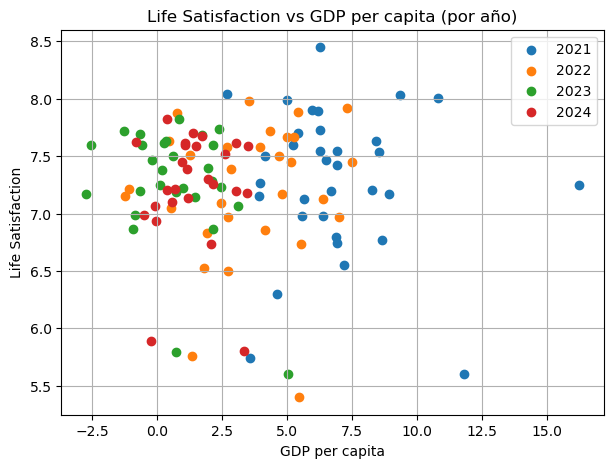

In [12]:
plt.figure(figsize=(7,5))

for year in sorted(df_merged["TIME_PERIOD"].unique()):
    subset = df_merged[df_merged["TIME_PERIOD"] == year]
    plt.scatter(subset["gdp_per_capita"], subset["life_satisfaction"], label=str(year))

plt.xlabel("GDP per capita")
plt.ylabel("Life Satisfaction")
plt.title("Life Satisfaction vs GDP per capita (por año)")
plt.legend()
plt.grid(True)

plt.show()


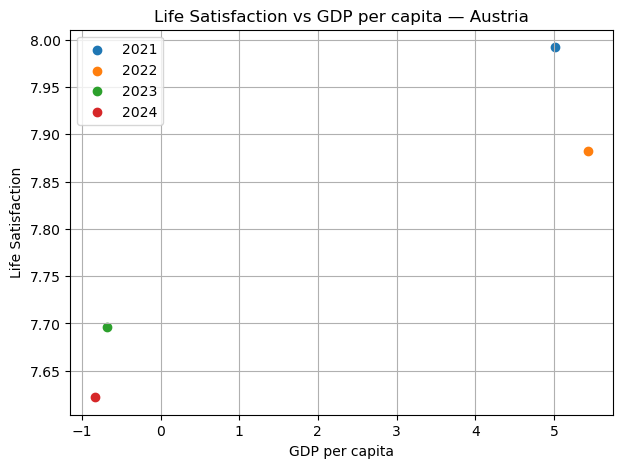

In [13]:
pais = "Austria"   
df_pais = df_merged[df_merged["Reference area"] == pais]

plt.figure(figsize=(7,5))

for year in sorted(df_pais["TIME_PERIOD"].unique()):
    subset = df_pais[df_pais["TIME_PERIOD"] == year]
    plt.scatter(
        subset["gdp_per_capita"], 
        subset["life_satisfaction"], 
        label=str(year)
    )

plt.xlabel("GDP per capita")
plt.ylabel("Life Satisfaction")
plt.title(f"Life Satisfaction vs GDP per capita — {pais}")
plt.legend()
plt.grid(True)

plt.show()